# 03 -- Train the U-Net

Trains a U-Net (`segmentation-models-pytorch`, ResNet34 encoder, ImageNet-pretrained)
on the masks built in notebook 02, evaluated on the held-out **test** split from
`data/split.json` -- the same split notebook 04's YOLO model is evaluated on.

**Meant to run on a free GPU notebook (Colab/Kaggle)** with the full downloaded
dataset (`--n 300`+) and a real epoch count (`EPOCHS = 30` is a reasonable start).
The output cells committed to this notebook are instead a **smoke test** -- a handful
of epochs on the 20-chip sample this repo verified everything against -- proving the
training code itself runs correctly end to end. Its metrics are **not meant to be
real results**; retrain properly before reading anything into the numbers.

In [1]:
import sys
sys.path.insert(0, '..')

import json
import os

import numpy as np
import segmentation_models_pytorch as smp
import torch
from PIL import Image
from torch.utils.data import DataLoader, Dataset

from src.split import load_split

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

# Set EPOCHS = 30+ for a real run on a GPU. This notebook's own committed
# output used a small value -- see the markdown note above.
EPOCHS = 5
BATCH_SIZE = 4
LR = 1e-3


device: cpu


## Dataset

In [2]:
class BuildingSegmentationDataset(Dataset):
    def __init__(self, chip_ids, images_dir='../data/unet/images', masks_dir='../data/unet/masks'):
        self.chip_ids = chip_ids
        self.images_dir = images_dir
        self.masks_dir = masks_dir

    def __len__(self):
        return len(self.chip_ids)

    def __getitem__(self, idx):
        chip_id = self.chip_ids[idx]
        image = np.array(Image.open(f'{self.images_dir}/img{chip_id}.png').convert('RGB'), dtype='float32') / 255.0
        mask = np.array(Image.open(f'{self.masks_dir}/img{chip_id}.png'), dtype='float32') / 255.0
        image = torch.from_numpy(image).permute(2, 0, 1)  # HWC -> CHW
        mask = torch.from_numpy(mask).unsqueeze(0)  # HW -> 1HW
        return image, mask


split = load_split('../data/split.json')
train_ds = BuildingSegmentationDataset(split['train'])
val_ds = BuildingSegmentationDataset(split['val'])
test_ds = BuildingSegmentationDataset(split['test'])
print(f'train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


train: 14, val: 3, test: 3


## Model, loss, optimizer

Dice + BCE, not plain BCE alone -- most of any chip's pixels are *not* building
(mean ~17% in notebook 02's real sample), and plain BCE tends to just learn to
predict "nothing" under that imbalance.

In [3]:
model = smp.Unet(encoder_name='resnet34', encoder_weights='imagenet', in_channels=3, classes=1).to(DEVICE)
loss_fn = smp.losses.DiceLoss(mode='binary') 
bce_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)


def combined_loss(logits, target):
    return loss_fn(logits, target) + bce_fn(logits, target)


## Train

In [4]:
history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []
    for images, masks in train_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss = combined_loss(logits, masks)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses = []
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            logits = model(images)
            val_losses.append(combined_loss(logits, masks).item())

    history['train_loss'].append(np.mean(train_losses))
    history['val_loss'].append(np.mean(val_losses))
    print(f"epoch {epoch}/{EPOCHS}  train_loss={history['train_loss'][-1]:.4f}  val_loss={history['val_loss'][-1]:.4f}")


epoch 1/5  train_loss=1.3415  val_loss=1.6324


epoch 2/5  train_loss=0.9802  val_loss=1.4949


epoch 3/5  train_loss=0.8252  val_loss=0.9805


epoch 4/5  train_loss=0.7266  val_loss=1.1692


epoch 5/5  train_loss=0.6301  val_loss=2.4014


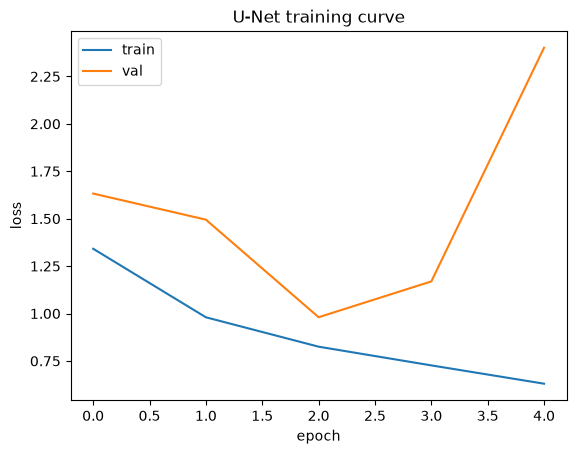

In [5]:
import matplotlib.pyplot as plt

plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.title('U-Net training curve')
plt.show()


## Evaluate on the held-out test split

IoU and F1 for the "building" class -- the same test chip ids `data/split.json`
gave to the YOLO notebook, so notebook 05's comparison is apples-to-apples.

In [6]:
def iou_and_f1(pred_mask, true_mask, threshold=0.5):
    pred = pred_mask > threshold
    true = true_mask > threshold
    intersection = (pred & true).sum()
    union = (pred | true).sum()
    iou = intersection / union if union > 0 else 1.0
    precision_denom = pred.sum()
    recall_denom = true.sum()
    precision = intersection / precision_denom if precision_denom > 0 else 1.0
    recall = intersection / recall_denom if recall_denom > 0 else 1.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return iou, f1


model.eval()
ious, f1s = [], []
with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(DEVICE)
        preds = torch.sigmoid(model(images)).cpu().numpy()
        true = masks.numpy()
        for p, t in zip(preds, true):
            iou, f1 = iou_and_f1(p[0], t[0])
            ious.append(iou)
            f1s.append(f1)

test_iou = float(np.mean(ious))
test_f1 = float(np.mean(f1s))
print(f'test IoU: {test_iou:.3f}')
print(f'test F1:  {test_f1:.3f}')


test IoU: 0.280
test F1:  0.400


## Save the trained weights + metrics

In [7]:
os.makedirs('../runs', exist_ok=True)
torch.save(model.state_dict(), '../runs/unet.pt')

with open('../runs/unet_metrics.json', 'w') as f:
    json.dump({'test_iou': test_iou, 'test_f1': test_f1, 'epochs': EPOCHS, 'n_train': len(train_ds)}, f, indent=2)

print('saved ../runs/unet.pt and ../runs/unet_metrics.json')


saved ../runs/unet.pt and ../runs/unet_metrics.json


## Done when

- [ ] Trained on the **full** downloaded dataset (`--n 300`+), not the 20-chip sample.
- [ ] `EPOCHS` high enough that the val loss curve has actually flattened, not still
  dropping when training stopped.
- [ ] Test IoU > 0.75 and F1 correspondingly high, per the practice plan's target
  (this notebook's own committed smoke-test numbers will **not** meet this -- see the
  intro note).